In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


#Task 1


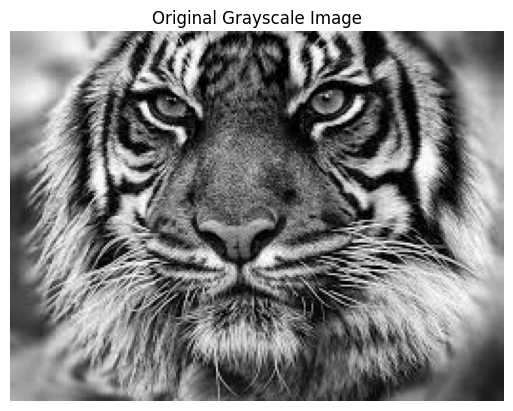

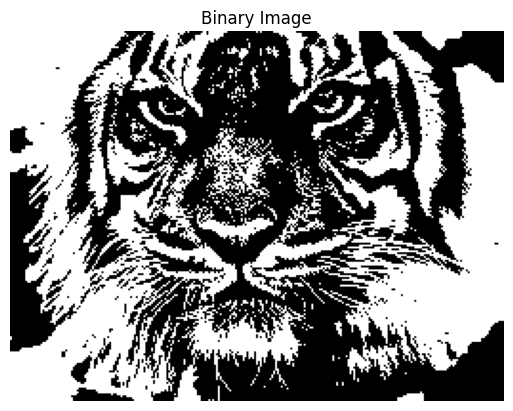

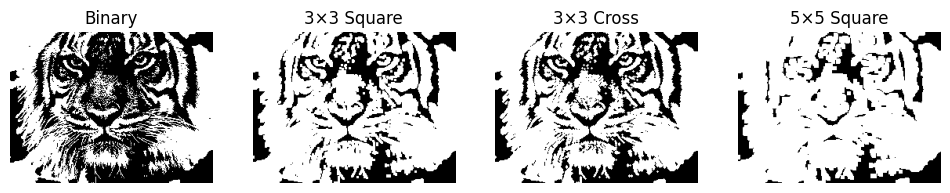

In [18]:
img = cv2.imread("sample3.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()
_, binary = cv2.threshold(img, 120, 255, cv2.THRESH_BINARY)

plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()
#SEs
se_square_3 = np.ones((3,3), np.uint8)

se_cross_3 = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))

se_square_5 = np.ones((5,5), np.uint8)
#dilation
dil_square_3 = cv2.dilate(binary, se_square_3)
dil_cross_3  = cv2.dilate(binary, se_cross_3)
dil_square_5 = cv2.dilate(binary, se_square_5)
#Dis results
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(binary, cmap="gray")
plt.title("Binary")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(dil_square_3, cmap="gray")
plt.title("3×3 Square")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(dil_cross_3, cmap="gray")
plt.title("3×3 Cross")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(dil_square_5, cmap="gray")
plt.title("5×5 Square")
plt.axis("off")

plt.show()


Larger and denser structuring elements cause faster and more uniform object growth, while cross-shaped SEs grow objects more selectively along vertical and horizontal directions.

# Task 2


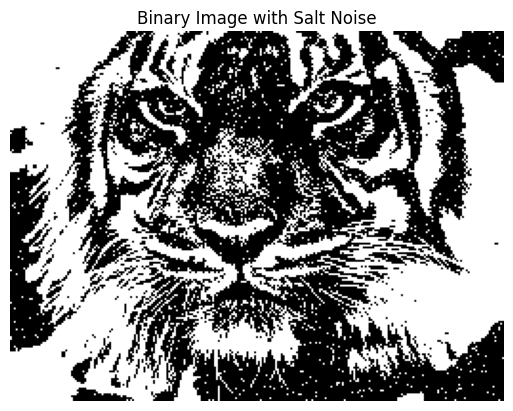

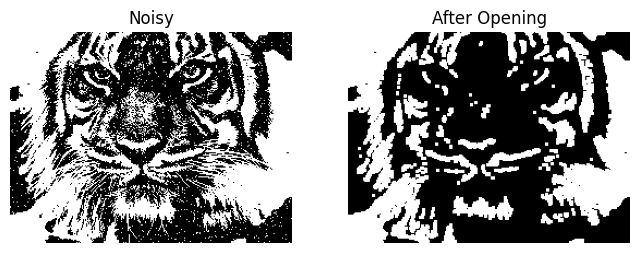

In [19]:
noisy = binary.copy()
num_noise = 2000

noisy = binary.copy()
num_noise = 2000

rows, cols = noisy.shape

for _ in range(num_noise):
    x = np.random.randint(0, rows)
    y = np.random.randint(0, cols)
    noisy[x, y] = 255

plt.imshow(noisy, cmap="gray")
plt.title("Binary Image with Salt Noise")
plt.axis("off")
plt.show()
kernel = np.ones((3,3), np.uint8)
cleaned = cv2.morphologyEx(noisy, cv2.MORPH_OPEN, kernel)
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(noisy, cmap="gray")
plt.title("Noisy")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cleaned, cmap="gray")
plt.title("After Opening")
plt.axis("off")

plt.show()

Morphological opening was most effective as it removed isolated noise pixels while preserving the main object shape.

# Task 3


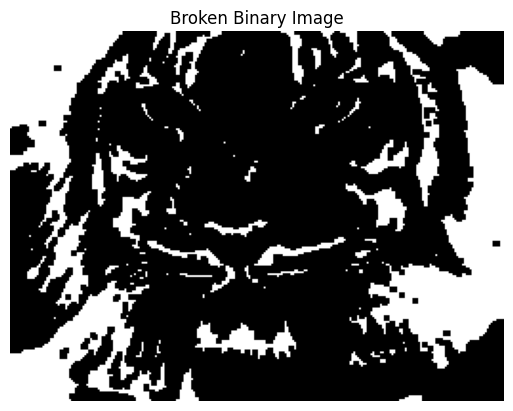

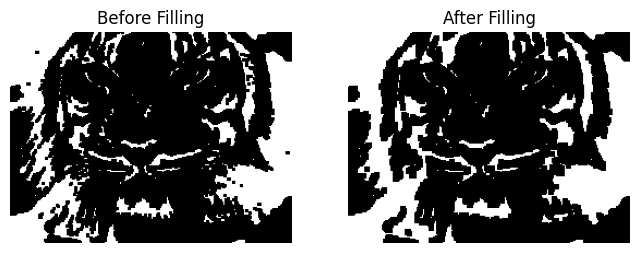

In [20]:
broken = cv2.erode(binary, np.ones((3,3), np.uint8), iterations=1)

plt.imshow(broken, cmap="gray")
plt.title("Broken Binary Image")
plt.axis("off")
plt.show()
kernel = np.ones((5,5), np.uint8)
filled = cv2.morphologyEx(broken, cv2.MORPH_CLOSE, kernel)
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(broken, cmap="gray")
plt.title("Before Filling")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(filled, cmap="gray")
plt.title("After Filling")
plt.axis("off")

plt.show()


If the structuring element is too large, object boundaries become distorted and fine details are lost.

# Task 5

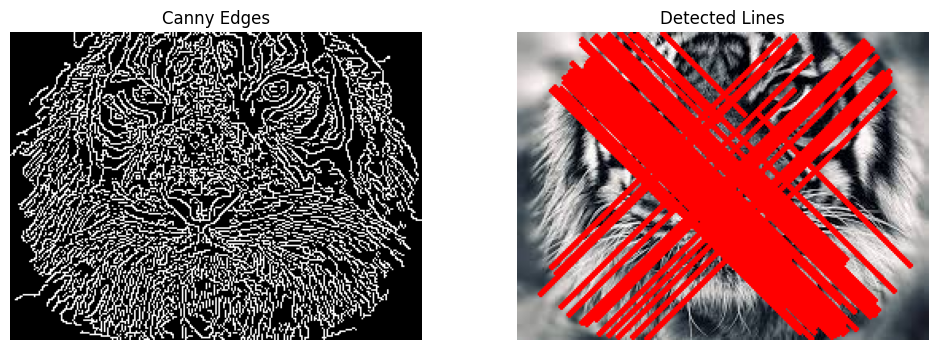

In [23]:
#Canny ed
edges = cv2.Canny(img, 100, 200)

#Hough Line Transform
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,
    threshold=100,      # change this ONE parameter to observe effect
    minLineLength=50,
    maxLineGap=10
)

#lines on original image
line_img = img.copy()

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Dis results
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Lines")
plt.axis("off")

plt.show()


 When the Hough threshold is too low, many false lines appear
 because weak edge alignments are also treated as valid lines.


# Task 6

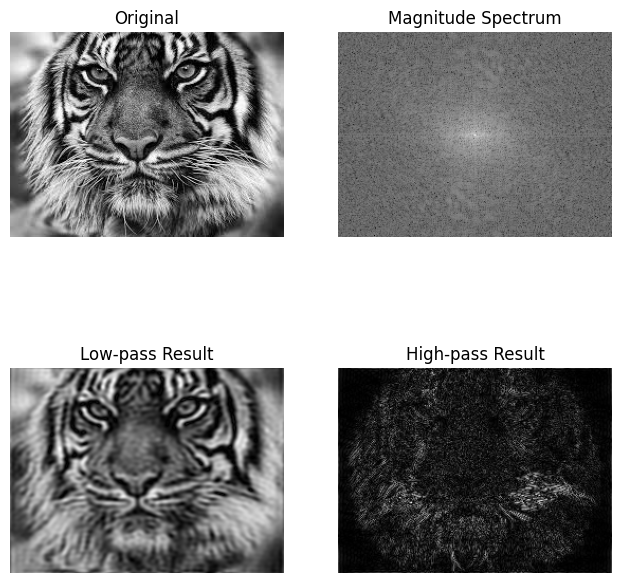

In [24]:
if len(img.shape) == 3:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#FFT
fft = np.fft.fft2(img)
fft_shift = np.fft.fftshift(fft)

# Magnitude spectrum
magnitude = np.log(1 + np.abs(fft_shift))

#Create filters
rows, cols = img.shape
crow, ccol = rows//2, cols//2

# Low-pass filter
lpf = np.zeros((rows, cols), np.uint8)
cv2.circle(lpf, (ccol, crow), 40, 1, -1)

# High-pass filter
hpf = 1 - lpf

#Apply filters
low_freq = fft_shift * lpf
high_freq = fft_shift * hpf

#Inverse FFT
img_low = np.abs(np.fft.ifft2(np.fft.ifftshift(low_freq)))
img_high = np.abs(np.fft.ifft2(np.fft.ifftshift(high_freq)))

# Dis results
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(magnitude, cmap="gray")
plt.title("Magnitude Spectrum")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(img_low, cmap="gray")
plt.title("Low-pass Result")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(img_high, cmap="gray")
plt.title("High-pass Result")
plt.axis("off")

plt.show()


High-pass filtering enhances edges and fine details,
while low-pass filtering removes edges and smooths the image.


# Task 4

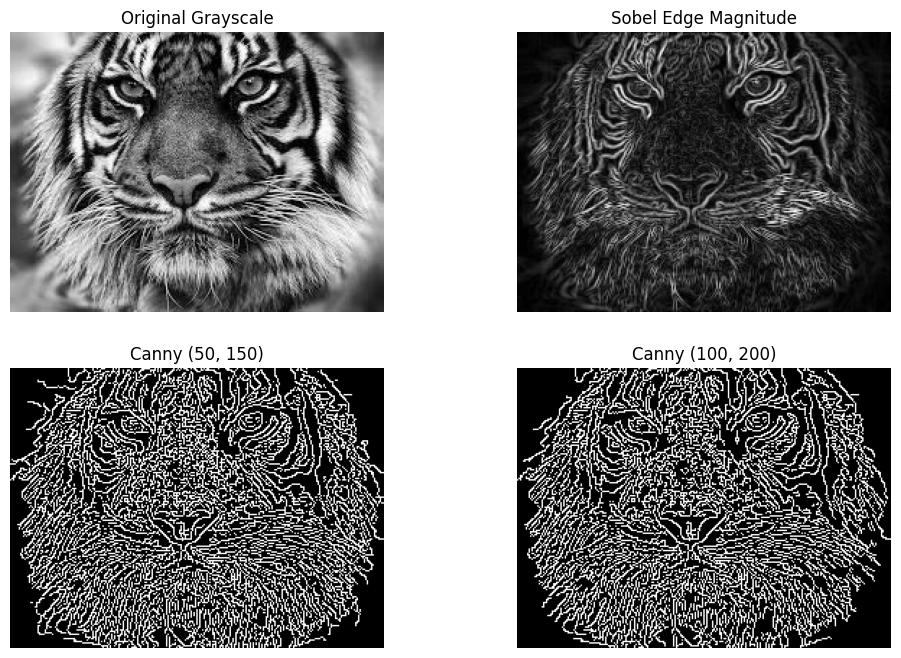

In [25]:
# Sobel ed
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag = np.uint8(255 * sobel_mag / np.max(sobel_mag))

# Canny with two threshold pairs
canny_1 = cv2.Canny(img, 50, 150)
canny_2 = cv2.Canny(img, 100, 200)

# Display results
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(sobel_mag, cmap="gray")
plt.title("Sobel Edge Magnitude")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(canny_1, cmap="gray")
plt.title("Canny (50, 150)")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(canny_2, cmap="gray")
plt.title("Canny (100, 200)")
plt.axis("off")

plt.show()


 As Canny thresholds increase, weak texture edges disappear first,
 while strong object boundaries remain.
 Sobel responds strongly to noise and texture compared to Canny.

# Task 7

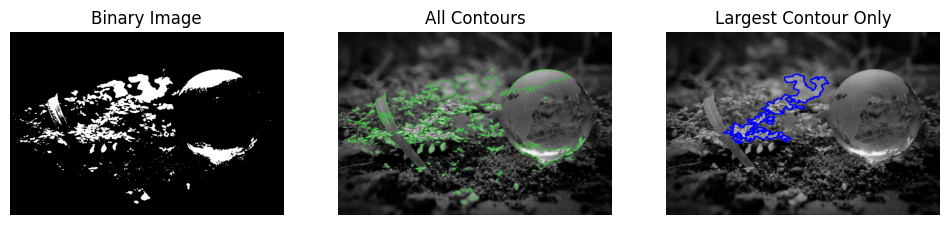

In [33]:
img = cv2.imread("sample1.jpg", cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 120, 255, cv2.THRESH_BINARY)
#contours
contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Convert grayscale to BGR for drawing
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Draw all contours
all_contours_img = img_color.copy()
cv2.drawContours(all_contours_img, contours, -1, (0,255,0), 1)

# Find and draw largest contour
largest_contour = max(contours, key=cv2.contourArea)

largest_contour_img = img_color.copy()
cv2.drawContours(largest_contour_img, [largest_contour], -1, (255,0,0), 2)

# Dis results
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(all_contours_img, cv2.COLOR_BGR2RGB))
plt.title("All Contours")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(largest_contour_img, cv2.COLOR_BGR2RGB))
plt.title("Largest Contour Only")
plt.axis("off")

plt.show()


Poor thresholding produces broken or merged contours,
leading to incorrect object boundary detection.

# Challenge

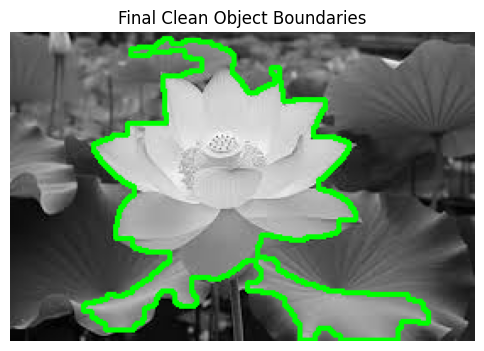

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("sample4.jpg", cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 120, 255, cv2.THRESH_BINARY)
kernel = np.ones((5,5), np.uint8)

clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel)
edges = cv2.Canny(clean, 100, 200)
contours, _ = cv2.findContours(
    clean,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
min_area = 1000  # adjust once, not blindly
significant_contours = [
    c for c in contours if cv2.contourArea(c) > min_area
]
final_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

cv2.drawContours(
    final_img,
    significant_contours,
    -1,
    (0, 255, 0),
    2
)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
plt.title("Final Clean Object Boundaries")
plt.axis("off")
plt.show()

